In [2]:
import json
import math
import hashlib
from pathlib import Path
from collections.abc import Mapping
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = "data/export.events.json"
FIGURES_PATH = Path("figures")
FIGURES_PATH.mkdir(exist_ok=True)

In [3]:
# CHARGEMENT

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Nombre d'événements chargés : {len(data)}")

Nombre d'événements chargés : 11948


In [4]:
def unwrap_mongo_value(x):
    """
    Extrait les valeurs Mongo les plus courantes.
    """
    if isinstance(x, Mapping):
        if "$date" in x:
            return x["$date"]
        if "$oid" in x:
            return x["$oid"]
        if "$numberLong" in x:
            return x["$numberLong"]
    return x


def safe_len(x):
    if isinstance(x, list):
        return len(x)
    if isinstance(x, str):
        return len(x)
    return 0


def first_label(labels):
    if isinstance(labels, list) and len(labels) > 0:
        return labels[0]
    return None


def simplify_taxonomy(value, level=None):
    if not isinstance(value, str):
        return None
    parts = value.split("/")
    if level is None:
        return parts[-1]
    return "/".join(parts[:level])


def normalize_text(x):
    if not isinstance(x, str):
        return ""
    return " ".join(x.lower().split())


def hash_text(x):
    return hashlib.md5(normalize_text(x).encode("utf-8")).hexdigest()


def parse_dt(x):
    """
    Parse robuste pour dates Mongo / JSON.
    Ne transmet jamais un Mapping brut à pandas.
    """
    if x is None:
        return pd.NaT

    # Cas Mongo / dict-like
    if isinstance(x, Mapping):
        if "$date" in x:
            x = x["$date"]
        elif "$numberLong" in x:
            try:
                return pd.to_datetime(int(x["$numberLong"]), unit="ms", utc=True, errors="coerce")
            except Exception:
                return pd.NaT
        else:
            return pd.NaT

    # Cas structures non attendues
    if isinstance(x, (list, tuple, set)):
        return pd.NaT

    # Cas timestamp numérique
    if isinstance(x, (int, float)):
        try:
            return pd.to_datetime(x, utc=True, errors="coerce")
        except Exception:
            return pd.NaT

    # Cas texte ou objet simple
    try:
        return pd.to_datetime(str(x), errors="coerce", utc=True)
    except Exception:
        return pd.NaT

In [5]:
event_rows = []

for i, ev in enumerate(data):
    created_at = parse_dt(ev.get("createdAt"))
    end_at = parse_dt(ev.get("endAt"))

    context = ev.get("context", "")
    nodes = ev.get("nodes", [])
    edges = ev.get("edges", [])

    event_rows.append({
        "event_id": unwrap_mongo_value(ev.get("_id")),
        "createdAt": created_at,
        "endAt": end_at,
        "type": ev.get("type"),
        "type_lvl1": simplify_taxonomy(ev.get("type"), 1),
        "type_lvl2": simplify_taxonomy(ev.get("type"), 2),
        "type_lvl3": simplify_taxonomy(ev.get("type"), 3),
        "type_last": simplify_taxonomy(ev.get("type"), None),
        "domain": ev.get("domain"),
        "domain_last": simplify_taxonomy(ev.get("domain"), None),
        "subdomain": ev.get("subdomain"),
        "subdomain_last": simplify_taxonomy(ev.get("subdomain"), None),
        "risk": ev.get("risk"),
        "risk_last": simplify_taxonomy(ev.get("risk"), None),
        "riskCarac": ev.get("riskCarac"),
        "riskCarac_last": simplify_taxonomy(ev.get("riskCarac"), None),
        "sourceNodeId": ev.get("sourceNodeId"),
        "resultAnalyseId": ev.get("resultAnalyseId"),
        "taskId": ev.get("taskId"),
        "context": context,
        "context_chars": len(context) if isinstance(context, str) else 0,
        "context_words": len(context.split()) if isinstance(context, str) else 0,
        "context_hash": hash_text(context),
        "n_nodes": len(nodes) if isinstance(nodes, list) else 0,
        "n_edges": len(edges) if isinstance(edges, list) else 0,
        "_class": ev.get("_class")
    })

events_df = pd.DataFrame(event_rows)

events_df["graph_density_directed"] = events_df.apply(
    lambda r: r["n_edges"] / (r["n_nodes"] * (r["n_nodes"] - 1))
    if r["n_nodes"] > 1 else 0,
    axis=1
)

events_df["edge_node_ratio"] = events_df.apply(
    lambda r: r["n_edges"] / r["n_nodes"] if r["n_nodes"] > 0 else np.nan,
    axis=1
)

events_df.head()

,event_id,createdAt,endAt,type,type_lvl1,type_lvl2,type_lvl3,type_last,domain,domain_last,...,taskId,context,context_chars,context_words,context_hash,n_nodes,n_edges,_class,graph_density_directed,edge_node_ratio
0,698b35e78f03efde04a87998,2026-02-10 13:43:03.827000+00:00,NaT,Thing/Abstract/Event/Win,Thing,Thing/Abstract,Thing/Abstract/Event,Win,NaN,NaN,...,1a076139-ea5e-40e2-8d82-01a1f28b8181,Portrait des six principaux candidats qui sont...,164,27,2e1b77de95e4c51fc56ea9b066f1239a,3,2,com.emvista.charlie.infrastructure.persistence...,0.333333,0.666667
1,698b35e98f03efde04a8799a,2026-02-10 13:43:05.544000+00:00,2026-02-10 13:42:59.932000+00:00,Thing/Abstract/Event/Transfer/TransferOfUnbias...,Thing,Thing/Abstract,Thing/Abstract/Event,TransferOfUnbiasedInformation,Thing/Abstract/Event/Spying,Spying,...,9c1f0cb5-58ed-44db-b348-1bb5e5cc3c75,Des e-mails publiés par le département américa...,119,20,8a2e9461b77c3734cbbf48070249692e,3,2,com.emvista.charlie.infrastructure.persistence...,0.333333,0.666667
2,698b35e98f03efde04a8799b,2026-02-10 13:43:05.544000+00:00,NaT,Thing/Abstract/Event/Transfer/TransferOfUnbias...,Thing,Thing/Abstract,Thing/Abstract/Event,TransferOfUnbiasedInformation,Thing/Abstract/Event/Spying,Spying,...,9c1f0cb5-58ed-44db-b348-1bb5e5cc3c75,Des e-mails publiés par le département américa...,173,28,789113679493e46632781216d0b2d66f,3,2,com.emvista.charlie.infrastructure.persistence...,0.333333,0.666667
3,698b35e98f03efde04a8799c,2026-02-10 13:43:05.544000+00:00,NaT,Thing/Abstract/Event/Build,Thing,Thing/Abstract,Thing/Abstract/Event,Build,Thing/Abstract/Event/Spying,Spying,...,9c1f0cb5-58ed-44db-b348-1bb5e5cc3c75,ervi de facilitateur à des représentants de l’...,129,18,c9fdb5aad5d316315eb197c5a495d686,1,0,com.emvista.charlie.infrastructure.persistence...,0.000000,0.000000
4,698b35e98f03efde04a8799d,2026-02-10 13:43:05.544000+00:00,NaT,Thing/Abstract/Event/Addition,Thing,Thing/Abstract,Thing/Abstract/Event,Addition,Thing/Abstract/Event/Spying,Spying,...,9c1f0cb5-58ed-44db-b348-1bb5e5cc3c75,Des e-mails publiés par le département américa...,190,31,c63ef10ffb531a149ccbcd4da346fc48,3,2,com.emvista.charlie.infrastructure.persistence...,0.333333,0.666667


In [6]:
endat_types = Counter(type(ev.get("endAt")).__name__ for ev in data)
print(endat_types)

events_df[["createdAt", "endAt"]].isna().sum()

Counter({'NoneType': 7971, 'dict': 3977})


createdAt       0
endAt        8113
dtype: int64

In [7]:
events_df["endAt"].notna().mean() * 100

np.float64(32.09742216270505)

In [8]:
node_rows = []
edge_rows = []

for ev in data:
    event_id = unwrap_mongo_value(ev.get("_id"))
    ev_type = ev.get("type")
    ev_domain = ev.get("domain")
    ev_subdomain = ev.get("subdomain")
    ev_risk = ev.get("risk")
    ev_riskCarac = ev.get("riskCarac")
    ev_resultAnalyseId = ev.get("resultAnalyseId")
    ev_taskId = ev.get("taskId")
    created_at = parse_dt(ev.get("createdAt"))
    context = ev.get("context", "")

    nodes = ev.get("nodes", [])
    edges = ev.get("edges", [])

    if not isinstance(nodes, list):
        nodes = []
    if not isinstance(edges, list):
        edges = []

    # -----------------
    # NODES
    # -----------------
    for node in nodes:
        if not isinstance(node, dict):
            continue

        props = node.get("properties", {})
        if not isinstance(props, dict):
            props = {}

        labels = node.get("labels", [])
        if not isinstance(labels, list):
            labels = []

        node_rows.append({
            "event_id": event_id,
            "event_type": ev_type,
            "event_type_last": simplify_taxonomy(ev_type, None),
            "event_domain": ev_domain,
            "event_subdomain": ev_subdomain,
            "event_risk": ev_risk,
            "event_riskCarac": ev_riskCarac,
            "resultAnalyseId": ev_resultAnalyseId,
            "taskId": ev_taskId,
            "createdAt": created_at,
            "context": context,
            "node_id": node.get("_id"),
            "form": node.get("form"),
            "form_norm": normalize_text(node.get("form")),
            "form_len": len(node.get("form")) if isinstance(node.get("form"), str) else 0,
            "labels": labels,
            "node_label": first_label(labels),
            "node_label_last": simplify_taxonomy(first_label(labels), None),
            "mood": props.get("mood"),
            "aspect": props.get("aspect"),
            "category": props.get("category"),
            "tense": props.get("tense"),
            "polarity": props.get("polarity"),
            "raw_properties": props
        })

    # -----------------
    # EDGES
    # -----------------
    for edge in edges:
        if not isinstance(edge, dict):
            continue

        props = edge.get("properties", {})
        if not isinstance(props, dict):
            props = {}

        edge_rows.append({
            "event_id": event_id,
            "event_type": ev_type,
            "event_type_last": simplify_taxonomy(ev_type, None),
            "event_domain": ev_domain,
            "event_subdomain": ev_subdomain,
            "event_risk": ev_risk,
            "event_riskCarac": ev_riskCarac,
            "resultAnalyseId": ev_resultAnalyseId,
            "taskId": ev_taskId,
            "createdAt": created_at,
            "edge_id": edge.get("_id"),
            "edge_type": edge.get("type"),
            "source": edge.get("source"),
            "target": edge.get("target"),
            "raw_properties": props
        })

nodes_df = pd.DataFrame(node_rows)
edges_df = pd.DataFrame(edge_rows)

print("events_df :", events_df.shape)
print("nodes_df  :", nodes_df.shape)
print("edges_df  :", edges_df.shape)

nodes_df.head(), edges_df.head()

events_df : (11948, 28)
nodes_df  : (35702, 24)
edges_df  : (24395, 15)


(                   event_id  \
 0  698b35e78f03efde04a87998   
 1  698b35e78f03efde04a87998   
 2  698b35e78f03efde04a87998   
 3  698b35e98f03efde04a8799a   
 4  698b35e98f03efde04a8799a   
 
                                           event_type  \
 0                           Thing/Abstract/Event/Win   
 1                           Thing/Abstract/Event/Win   
 2                           Thing/Abstract/Event/Win   
 3  Thing/Abstract/Event/Transfer/TransferOfUnbias...   
 4  Thing/Abstract/Event/Transfer/TransferOfUnbias...   
 
                  event_type_last                 event_domain  \
 0                            Win                          NaN   
 1                            Win                          NaN   
 2                            Win                          NaN   
 3  TransferOfUnbiasedInformation  Thing/Abstract/Event/Spying   
 4  TransferOfUnbiasedInformation  Thing/Abstract/Event/Spying   
 
                  event_subdomain                    event_risk 

In [9]:
print(nodes_df.isna().sum().sort_values(ascending=False).head(10))
print(edges_df.isna().sum().sort_values(ascending=False).head(10))

event_riskCarac    28206
event_domain       25028
event_subdomain    23818
event_risk         22872
polarity           21349
mood               21349
tense              21349
category           21349
aspect             21349
event_id               0
dtype: int64
event_riskCarac    19292
event_domain       17153
event_subdomain    16342
event_risk         15691
event_type_last        0
event_id               0
event_type             0
resultAnalyseId        0
taskId                 0
createdAt              0
dtype: int64


In [10]:
nodes_df[["node_label", "mood", "aspect", "tense", "polarity"]].head()

,node_label,mood,aspect,tense,polarity
0,Thing/Abstract/Event/Win,INF,STATE,PRES,POS
1,Thing/Concrete/Inanimate,NaN,NaN,NaN,NaN
2,Thing/Abstract/Time,NaN,NaN,NaN,NaN
3,Thing/Abstract/Event/Transfer/TransferOfUnbias...,PART,STATE,PAST,POS
4,Thing/Abstract/Time,NaN,NaN,NaN,NaN


In [11]:
overview = pd.DataFrame({
    "indicateur": [
        "Nombre d'événements",
        "Nombre total de nœuds",
        "Nombre total d'arêtes",
        "Moyenne nœuds / événement",
        "Médiane nœuds / événement",
        "Moyenne arêtes / événement",
        "Médiane arêtes / événement",
        "Nombre de types d'événements distincts",
        "Nombre de labels de nœuds distincts",
        "Nombre de types d'arêtes distincts"
    ],
    "valeur": [
        len(events_df),
        len(nodes_df),
        len(edges_df),
        round(events_df["n_nodes"].mean(), 2),
        round(events_df["n_nodes"].median(), 2),
        round(events_df["n_edges"].mean(), 2),
        round(events_df["n_edges"].median(), 2),
        events_df["type"].nunique(dropna=True),
        nodes_df["node_label"].nunique(dropna=True),
        edges_df["edge_type"].nunique(dropna=True),
    ]
})

overview

,indicateur,valeur
0,Nombre d'événements,11948.00
1,Nombre total de nœuds,35702.00
2,Nombre total d'arêtes,24395.00
3,Moyenne nœuds / événement,2.99
4,Médiane nœuds / événement,3.00
5,Moyenne arêtes / événement,2.04
6,Médiane arêtes / événement,2.00
7,Nombre de types d'événements distincts,343.00
8,Nombre de labels de nœuds distincts,427.00
9,Nombre de types d'arêtes distincts,48.00


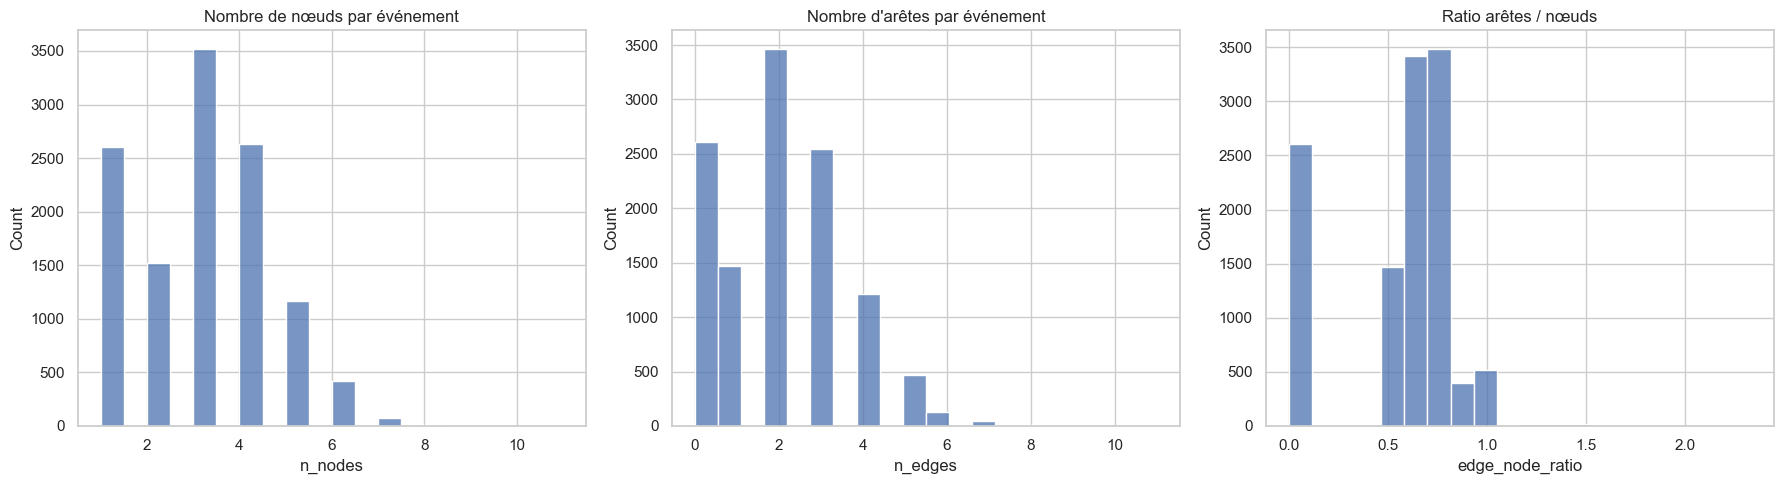

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(events_df["n_nodes"], bins=20, ax=axes[0])
axes[0].set_title("Nombre de nœuds par événement")
axes[0].set_xlabel("n_nodes")

sns.histplot(events_df["n_edges"], bins=20, ax=axes[1])
axes[1].set_title("Nombre d'arêtes par événement")
axes[1].set_xlabel("n_edges")

sns.histplot(events_df["edge_node_ratio"].dropna(), bins=20, ax=axes[2])
axes[2].set_title("Ratio arêtes / nœuds")
axes[2].set_xlabel("edge_node_ratio")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "01_distribution_graphique.png", dpi=300, bbox_inches="tight")
plt.show()

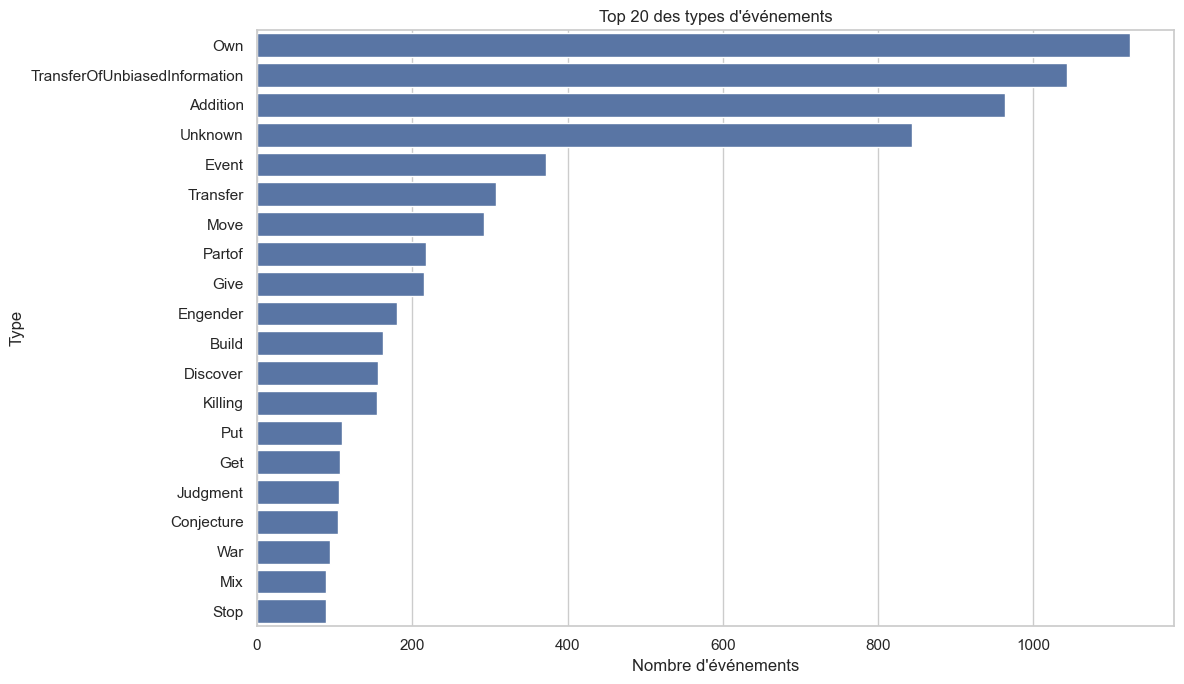

,count
type_last,
Own,1125
TransferOfUnbiasedInformation,1043
Addition,964
Unknown,844
Event,372
Transfer,308
Move,293
Partof,218
Give,215


In [13]:
top_types = events_df["type_last"].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_types.values, y=top_types.index)
plt.title("Top 20 des types d'événements")
plt.xlabel("Nombre d'événements")
plt.ylabel("Type")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "02_top_types_evenements.png", dpi=300, bbox_inches="tight")
plt.show()

top_types.to_frame("count")

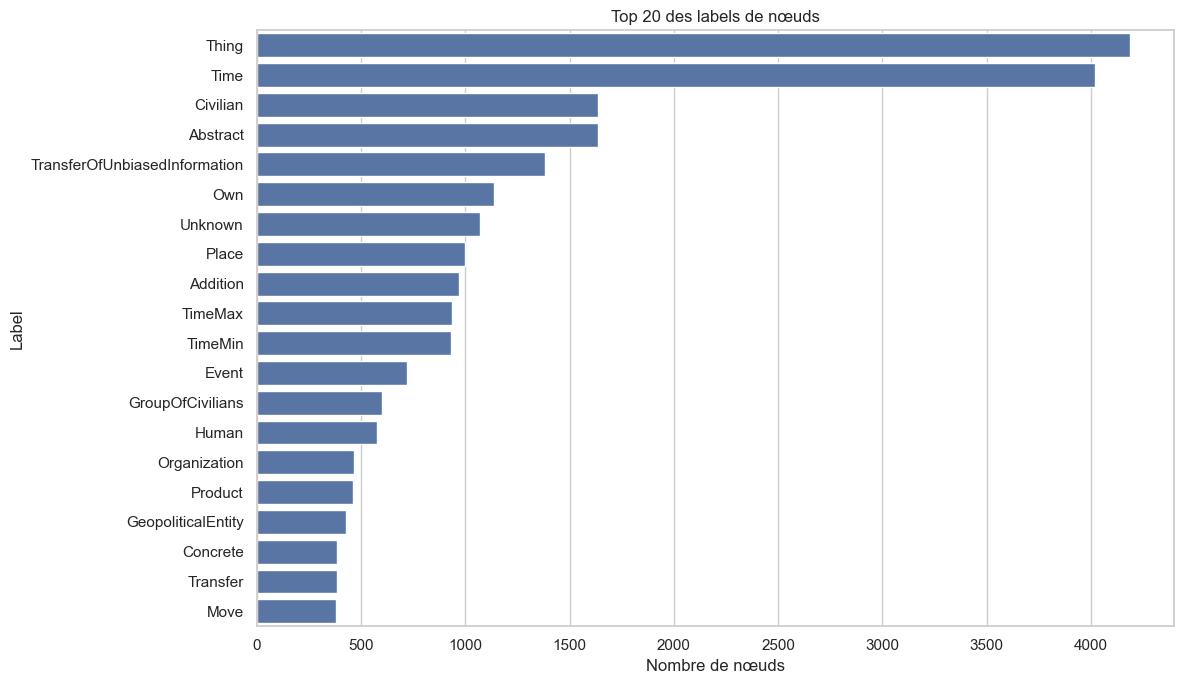

,count
node_label_last,
Thing,4189
Time,4019
Civilian,1635
Abstract,1635
TransferOfUnbiasedInformation,1380
Own,1135
Unknown,1068
Place,998
Addition,969


In [14]:
top_node_labels = nodes_df["node_label_last"].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_node_labels.values, y=top_node_labels.index)
plt.title("Top 20 des labels de nœuds")
plt.xlabel("Nombre de nœuds")
plt.ylabel("Label")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "03_top_labels_noeuds.png", dpi=300, bbox_inches="tight")
plt.show()

top_node_labels.to_frame("count")

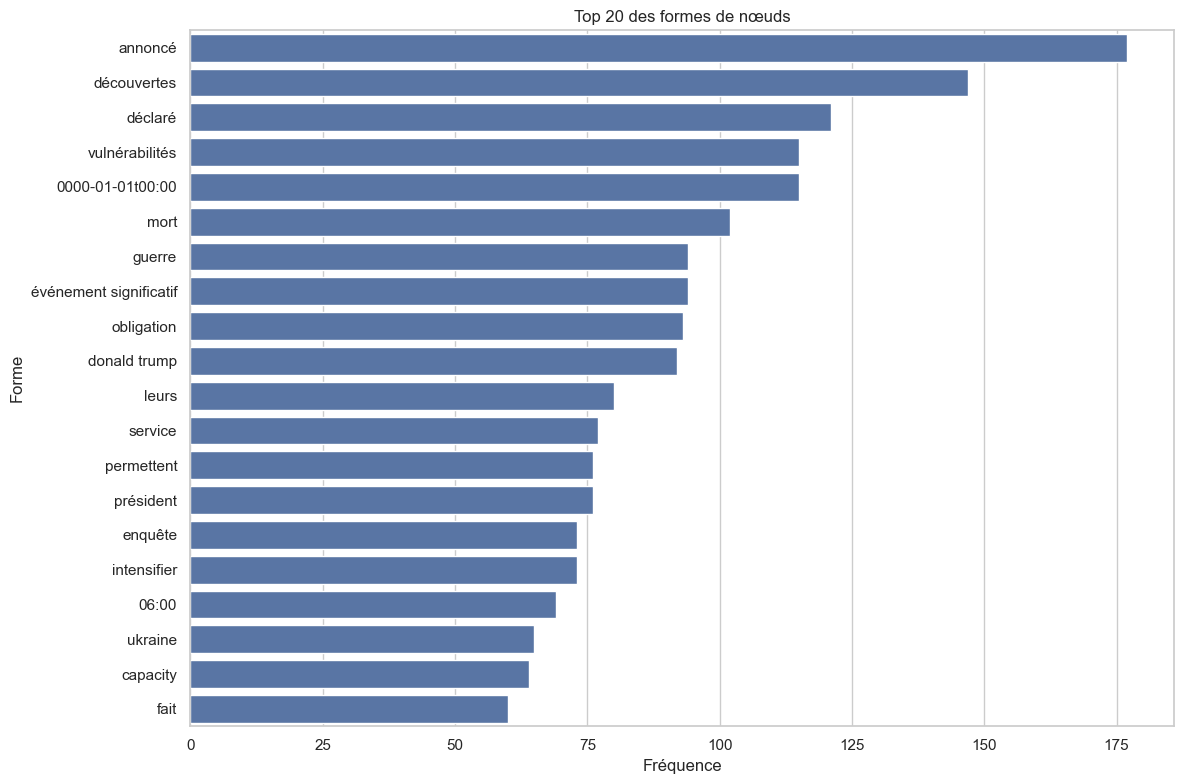

,count
form_norm,
annoncé,177
découvertes,147
déclaré,121
vulnérabilités,115
0000-01-01t00:00,115
mort,102
guerre,94
événement significatif,94
obligation,93


In [17]:
# filtrage simple
stopwords = {
    "et", "de", "la", "le", "les", "l'", "d'", "son", "sa", "ses",
    "un", "une", "des", "à", "en", "sur", "sous", "par",
    "pour", "avec", "sans", "dans", "entre", "vers", "du",
    "ou", "que", "qui", "où", "dont", "ce", "cet", "cette",
    "ces", "je", "tu", "il", "elle", "nous", "vous", "ils",
    "elles", "me", "te", "se", "lui", "leur", "y", "en",
    "est", "sont", "était", "étaient", "suis", "es", "étions",
    "étiez", "être", "avoir", "a", "ont", "avait", "avaient",
    "ai", "as", "avons", "avez", "rien", "aucun", "aucune",
    "autre", "ça", "cela", "celui", "celle", "même", "mêmes",
    "tout", "tous", "toute", "toutes", "quelque", "quelques"
}

nodes_df = nodes_df[~nodes_df["form_norm"].isin(stopwords)]

top_forms = (
    nodes_df["form_norm"]
    .dropna()
    .loc[lambda s: s.str.len() > 0]
    .value_counts()
    .head(30)
)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_forms.values[:20], y=top_forms.index[:20])
plt.title("Top 20 des formes de nœuds")
plt.xlabel("Fréquence")
plt.ylabel("Forme")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "04_top_formes_noeuds.png", dpi=300, bbox_inches="tight")
plt.show()

top_forms.head(20).to_frame("count")

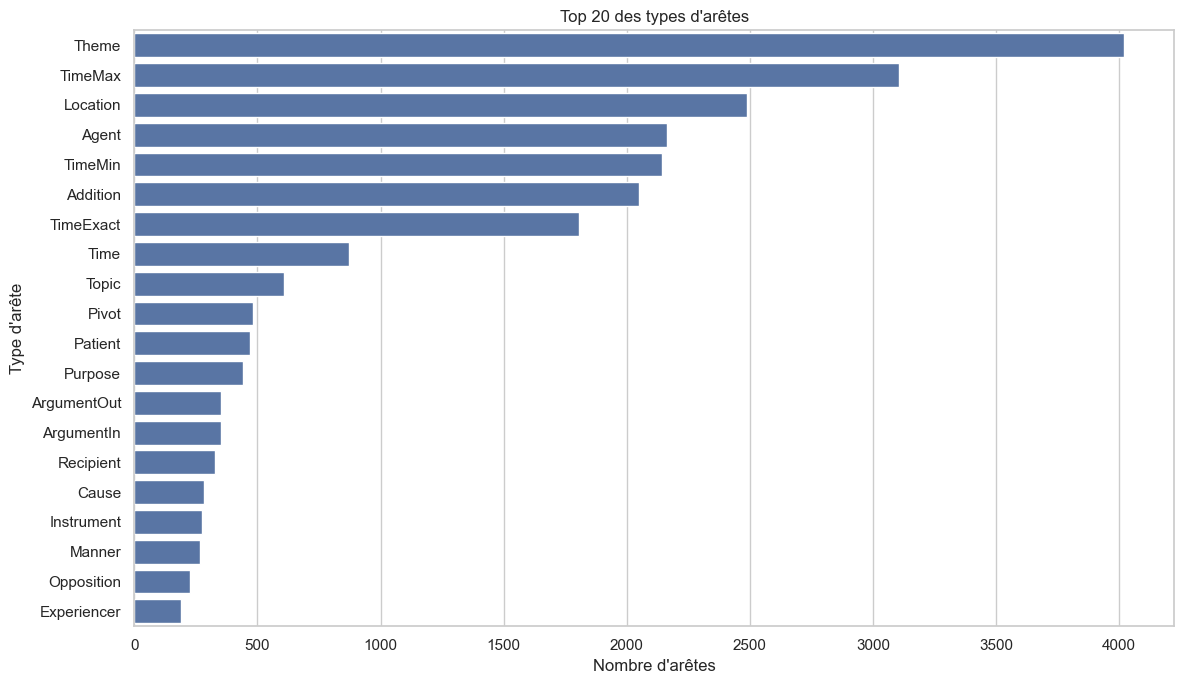

,count
edge_type,
Theme,4022
TimeMax,3108
Location,2487
Agent,2163
TimeMin,2142
Addition,2048
TimeExact,1807
Time,872
Topic,606


In [15]:
top_edges = edges_df["edge_type"].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_edges.values, y=top_edges.index)
plt.title("Top 20 des types d'arêtes")
plt.xlabel("Nombre d'arêtes")
plt.ylabel("Type d'arête")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "05_top_types_aretes.png", dpi=300, bbox_inches="tight")
plt.show()

top_edges.to_frame("count")

In [16]:
ling_nodes = nodes_df[
    nodes_df[["mood", "aspect", "tense", "polarity"]].notna().any(axis=1)
].copy()

print("Nombre de nœuds avec propriétés linguistiques :", len(ling_nodes))
ling_nodes[["node_label_last", "mood", "aspect", "tense", "polarity"]].head()

Nombre de nœuds avec propriétés linguistiques : 14353


,node_label_last,mood,aspect,tense,polarity
0,Win,INF,STATE,PRES,POS
3,TransferOfUnbiasedInformation,PART,STATE,PAST,POS
6,TransferOfUnbiasedInformation,IND,ATELIC_PROCESS,PRES,POS
7,TransferOfUnbiasedInformation,PART,STATE,PAST,POS
9,Build,EMPTY,PROCESS,EMPTY,POS


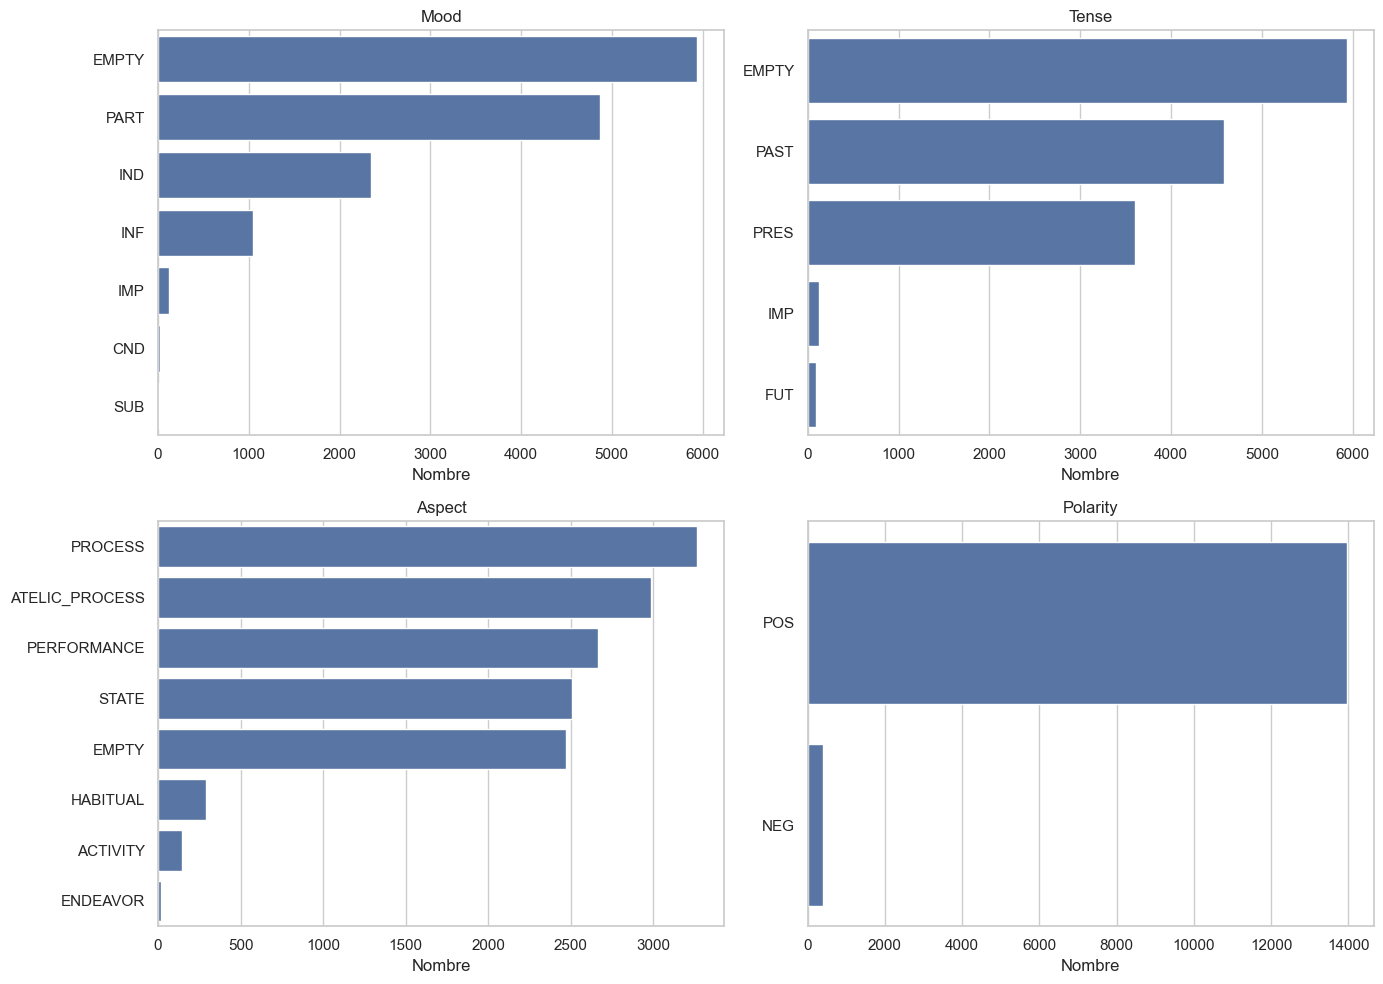

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title in zip(
    axes.flat,
    ["mood", "tense", "aspect", "polarity"],
    ["Mood", "Tense", "Aspect", "Polarity"]
):
    vc = ling_nodes[col].value_counts(dropna=False).head(10)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Nombre")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "06_proprietes_linguistiques.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
events_with_time_node = (
    nodes_df["node_label_last"]
    .fillna("")
    .eq("Time")
    .groupby(nodes_df["event_id"])
    .any()
    .rename("has_time_node")
)

events_with_time_edge = (
    edges_df["edge_type"]
    .fillna("")
    .str.contains("Time", regex=False)
    .groupby(edges_df["event_id"])
    .any()
    .rename("has_time_edge")
)

events_df = events_df.merge(events_with_time_node, on="event_id", how="left")
events_df = events_df.merge(events_with_time_edge, on="event_id", how="left")

events_df["has_time_node"] = events_df["has_time_node"].fillna(False)
events_df["has_time_edge"] = events_df["has_time_edge"].fillna(False)
events_df["has_temporal_info"] = events_df["has_time_node"] | events_df["has_time_edge"]

pd.DataFrame({
    "indicateur": ["Avec nœud temporel", "Avec arête temporelle", "Avec information temporelle"],
    "pourcentage": [
        round(events_df["has_time_node"].mean() * 100, 2),
        round(events_df["has_time_edge"].mean() * 100, 2),
        round(events_df["has_temporal_info"].mean() * 100, 2),
    ]
})

,indicateur,pourcentage
0,Avec nœud temporel,32.81
1,Avec arête temporelle,55.73
2,Avec information temporelle,56.41


In [19]:
events_df["flag_no_edges"] = events_df["n_edges"] == 0
events_df["flag_single_node"] = events_df["n_nodes"] <= 1
events_df["flag_no_time"] = ~events_df["has_temporal_info"]

events_df["anomaly_score_simple"] = (
    events_df["flag_no_edges"].astype(int)
    + events_df["flag_single_node"].astype(int)
    + events_df["flag_no_time"].astype(int)
)

pd.DataFrame({
    "indicateur": [
        "Sans arête",
        "1 nœud ou moins",
        "Sans information temporelle",
        "Score anomalie >= 2"
    ],
    "nb_evenements": [
        events_df["flag_no_edges"].sum(),
        events_df["flag_single_node"].sum(),
        events_df["flag_no_time"].sum(),
        (events_df["anomaly_score_simple"] >= 2).sum()
    ]
})

,indicateur,nb_evenements
0,Sans arête,2607
1,1 nœud ou moins,2608
2,Sans information temporelle,5208
3,Score anomalie >= 2,2608


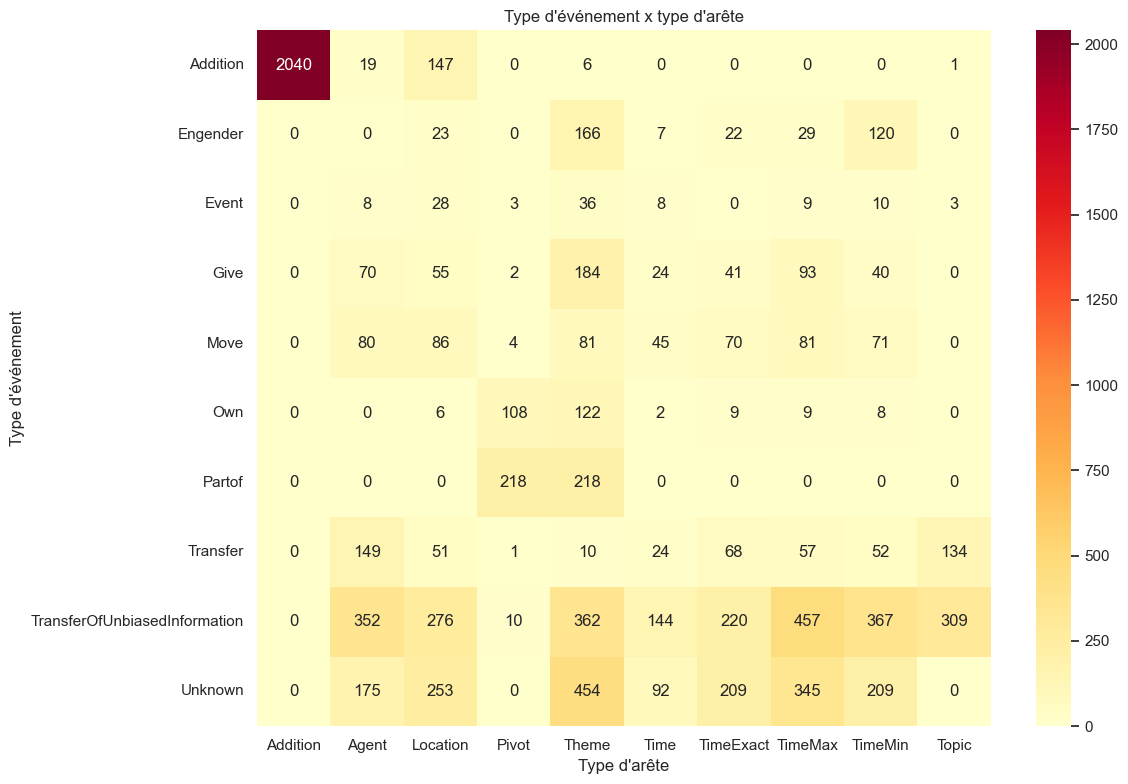

In [20]:
top_event_types = events_df["type_last"].value_counts().head(10).index
top_edge_types = edges_df["edge_type"].value_counts().head(10).index

heat_df = (
    edges_df[
        edges_df["event_type_last"].isin(top_event_types) &
        edges_df["edge_type"].isin(top_edge_types)
    ]
    .groupby(["event_type_last", "edge_type"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
sns.heatmap(heat_df, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Type d'événement x type d'arête")
plt.xlabel("Type d'arête")
plt.ylabel("Type d'événement")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "07_heatmap_evenement_x_arete.png", dpi=300, bbox_inches="tight")
plt.show()

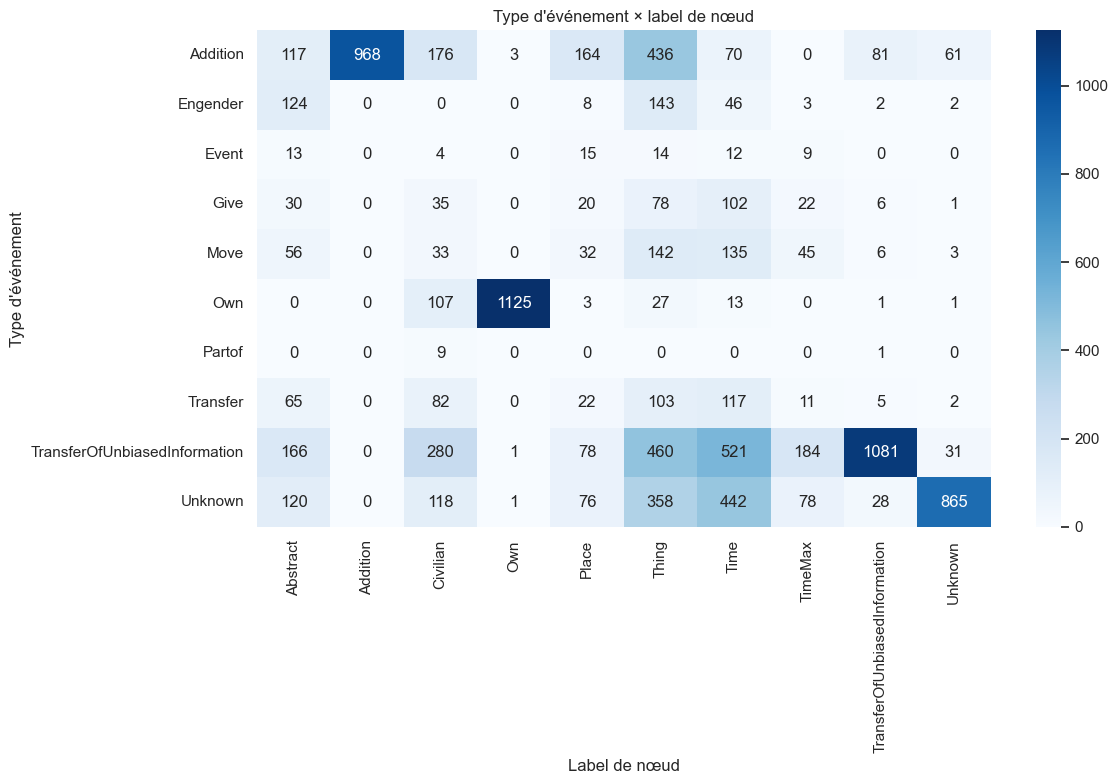

In [21]:
top_event_types = events_df["type_last"].value_counts().head(10).index
top_node_types = nodes_df["node_label_last"].value_counts().head(10).index

heat_nodes = (
    nodes_df[
        nodes_df["event_type_last"].isin(top_event_types) &
        nodes_df["node_label_last"].isin(top_node_types)
    ]
    .groupby(["event_type_last", "node_label_last"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
sns.heatmap(heat_nodes, annot=True, fmt="d", cmap="Blues")
plt.title("Type d'événement × label de nœud")
plt.xlabel("Label de nœud")
plt.ylabel("Type d'événement")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "08_heatmap_evenement_x_noeud.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
recap_type = (
    events_df.groupby("type_last")
    .agg(
        nb_events=("event_id", "count"),
        mean_nodes=("n_nodes", "mean"),
        mean_edges=("n_edges", "mean"),
        median_nodes=("n_nodes", "median"),
        median_edges=("n_edges", "median"),
        pct_temporal_info=("has_temporal_info", "mean"),
        pct_no_edges=("flag_no_edges", "mean"),
        mean_anomaly_score=("anomaly_score_simple", "mean")
    )
    .sort_values("nb_events", ascending=False)
)

recap_type["pct_temporal_info"] = (recap_type["pct_temporal_info"] * 100).round(2)
recap_type["pct_no_edges"] = (recap_type["pct_no_edges"] * 100).round(2)

recap_type.head(20)

,nb_events,mean_nodes,mean_edges,median_nodes,median_edges,pct_temporal_info,pct_no_edges,mean_anomaly_score
type_last,,,,,,,,
Own,1125,1.230222,0.235556,1.0,0.0,2.31,88.62,2.749333
TransferOfUnbiasedInformation,1043,3.729626,2.790029,4.0,3.0,91.47,4.79,0.181208
Addition,964,3.371369,2.376556,3.0,2.0,4.56,0.00,0.954357
Unknown,844,3.271327,2.309242,3.0,2.0,87.91,4.03,0.201422
Event,372,1.311828,0.322581,1.0,0.0,5.11,78.76,2.524194
Transfer,308,2.990260,2.045455,3.0,2.0,57.79,11.04,0.642857
Move,293,3.457338,2.535836,3.0,3.0,71.67,11.95,0.522184
Partof,218,3.000000,2.000000,3.0,2.0,0.00,0.00,1.000000
Give,215,3.590698,2.823256,4.0,3.0,80.00,7.91,0.358140
